# Figure: TKGU Operation Distribution (pie chart)

Produces `pie_chart_nr_triples_both.pdf`: pie chart showing the distribution of TKGU operations
in the full dataset vs the subsampled test set.

**Data sources:**
- Subsampled test set: from the refactored `WikiEvalResult` pkl
- Complete dataset: from old pipeline pkl (until full-dataset pipeline is ported)

In [1]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter

# src/ is 3 levels up from src/stats/dataset/
sys.path.insert(0, os.path.join(os.path.abspath('../../..'), 'src'))

from stats.evaluation.load_results import load_from_wiki_eval_result

In [2]:
# --- CONFIGURE THIS ---

# Subsampled test set (refactored pkl)
SUBSAMPLED_PKL = '/path/to/storage/emerge/output/experiments/s0x_evaluate_predictions/20260217_submitted_icml_fixed/wiki_eval_result.pkl'

# Complete dataset (old pipeline pkls — df_preds_gt_cie + df_instances needed)
# TODO: replace with refactored pkl once full-dataset pipeline is ported
COMPLETE_DATASET_DIR = '/path/to/storage/emerge/output/experiments/dataset_stats_pkls/20260124_all_dataset_no_models_v13_all/'

SAVE_DIR = '/path/to/storage/emerge/output/figures/'

In [3]:
# Load subsampled test set
(_, _, df_preds_gt_cie_sub, _, df_instances_sub, _) = load_from_wiki_eval_result(SUBSAMPLED_PKL)
df_preds_gt_cie_sub = df_preds_gt_cie_sub[df_preds_gt_cie_sub['triple_type'] == 'in-dataset']

# Join delta_weeks/snapshot_year from instances
if 'delta_weeks' not in df_preds_gt_cie_sub.columns:
    df_preds_gt_cie_sub = df_preds_gt_cie_sub.merge(
        df_instances_sub[['hash_id', 'delta_weeks', 'snapshot_year']],
        on='hash_id', how='inner')

print(f'Subsampled GT shape: {df_preds_gt_cie_sub.shape}')

# Load complete dataset (old pipeline: separate preds + instances pkls)
df_preds_gt_cie_all = pd.read_pickle(os.path.join(COMPLETE_DATASET_DIR, 'df_wiki_predictions_and_gt_cie.pkl'))
df_instances_all = pd.read_pickle(os.path.join(COMPLETE_DATASET_DIR, 'df_instances_v13.pkl'))

# Join delta_weeks/snapshot_year onto complete dataset
if 'delta_weeks' not in df_preds_gt_cie_all.columns:
    df_preds_gt_cie_all = df_preds_gt_cie_all.merge(
        df_instances_all[['hash_id', 'delta_weeks', 'snapshot_year']],
        on='hash_id', how='inner')

print(f'Complete dataset GT shape: {df_preds_gt_cie_all.shape}')
print(f'delta_weeks in complete: {sorted(df_preds_gt_cie_all.delta_weeks.unique())}')

Subsampled GT shape: (36245, 26)


Complete dataset GT shape: (3887196, 26)
delta_weeks in complete: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]


In [4]:
dict_stats = {
    'complete_dataset': {'df_preds_gt_cie': df_preds_gt_cie_all},
    'subsampled_dataset': {'df_preds_gt_cie': df_preds_gt_cie_sub},
}

# Assessor mappings per dataset
df_llm_assessors = {
    'complete_dataset': {
        'triple_assertion': 'Meta-Llama-3.1-8B_triple_assertion',
        'triple_deprecation': 'Meta-Llama-3.1-405B_triple_deprecation'
    },
    'subsampled_dataset': {
        # Refactored pipeline: assessor stored WITHOUT prompt_type suffix
        'triple_assertion': 'Meta-Llama-3.1-405B_prompt_v1',
        'triple_deprecation': 'Meta-Llama-3.1-405B_prompt_v1'
    }
}

# Shared constants
label_map = {
    'x-triples': 'Exists',
    'e-triples': 'Add',
    'ee-triples': 'Mint+Add',
    'ee-kg-triples': 'Infer',
    'd-triples': 'Deprecate',
}
tkgu_order = ['x-triples', 'e-triples', 'ee-triples', 'ee-kg-triples', 'd-triples']

map_key_to_title = {
    'complete_dataset': 'Complete dataset',
    'subsampled_dataset': 'Subsampled test set',
}

def filter_by_assessor(df, assessor_map):
    """Keep only rows evaluated by the expected assessor with strict bool result."""
    expected = df['prompt_type'].map(assessor_map)
    mask_expected = df['llm_assessor'].astype(str) == expected.astype(str)
    mask_bool = df['llm_assessor_result'].apply(lambda x: isinstance(x, (bool, np.bool_)))
    return df[mask_expected & mask_bool].copy()

## Pie chart: TKGU operation distribution

Saved to /path/to/storage/emerge/output/figures/


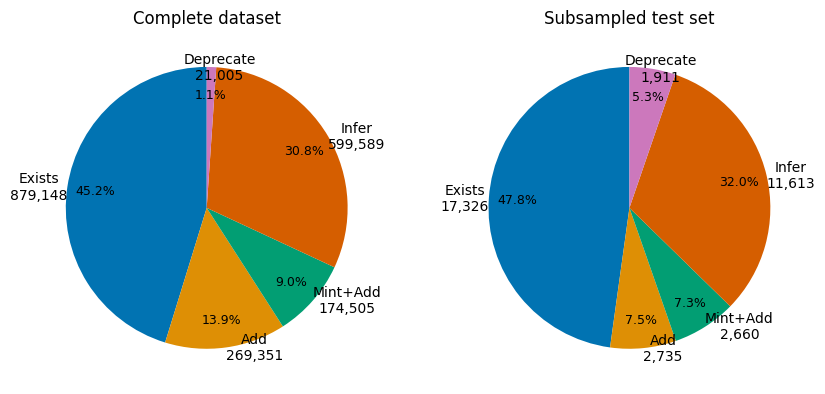

In [5]:
colors_pie = sns.color_palette('colorblind', 5)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

for ax, key in zip(axes, ['complete_dataset', 'subsampled_dataset']):
    df = dict_stats[key]['df_preds_gt_cie'].copy()
    df_eval = filter_by_assessor(df, df_llm_assessors[key])

    triple_counts = (
        df_eval['tkgu_type'].astype(str).str.strip().str.lower()
        .value_counts().reindex(tkgu_order, fill_value=0)
    )

    labels = [f"{label_map.get(t, t)}\n{int(c):,}" for t, c in triple_counts.items()]

    wedges, texts, autotexts = ax.pie(
        triple_counts.values, labels=labels, autopct='%1.1f%%',
        startangle=90, colors=colors_pie, labeldistance=1.0, pctdistance=0.8
    )

    if len(texts) > 4:
        x, y = texts[4].get_position()
        texts[4].set_position((x - 0.2, y))

    for t in texts:
        t.set_multialignment('center')
    for at in autotexts:
        at.set_color('black')
        at.set_fontsize(9)

    ax.set_title(map_key_to_title.get(key, key))

if SAVE_DIR:
    os.makedirs(SAVE_DIR, exist_ok=True)
    fig.savefig(os.path.join(SAVE_DIR, 'pie_chart_nr_triples_both.pdf'), bbox_inches='tight')
    fig.savefig(os.path.join(SAVE_DIR, 'pie_chart_nr_triples_both.png'), bbox_inches='tight', dpi=300)
    print(f'Saved to {SAVE_DIR}')

plt.show()